In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
df=pd.read_csv("data.csv", encoding='latin1')

/tmp/ipython-input-1327/1170420938.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data.csv", encoding='latin1')


In [7]:
x = df['no2'].dropna().values

In [6]:
print(df.columns)

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')


In [8]:
x = (x - np.mean(x)) / np.std(x)

In [9]:
r = 102303389

In [41]:
a_r = 0.5 * (r % 7)
b_r = 0.3 * (r % 5 + 1)
z = x + a * np.sin(b * x)
print(a_r)
print(b_r)

3.0
1.5


In [12]:
z_tensor = torch.tensor(z, dtype=torch.float32).view(-1, 1)

In [14]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

In [15]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [16]:
G = Generator()
D = Discriminator()
criterion = nn.BCELoss()
g_optimizer = optim.Adam(G.parameters(), lr=0.001)
d_optimizer = optim.Adam(D.parameters(), lr=0.001)

In [38]:
epochs = 7000
batch_size = 64
for epoch in range(epochs):
    idx = np.random.randint(0, z_tensor.shape[0], batch_size)
    real_data = z_tensor[idx]
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)
   # -------- Train Discriminator --------
    noise = torch.randn(batch_size, 1) # Changed from 2 to 1
    fake_data = G(noise)
    d_real = D(real_data)
    d_fake = D(fake_data.detach())
    d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()
    # -------- Train Generator --------
    noise = torch.randn(batch_size, 1) # Changed from 2 to 1
    fake_data = G(noise)
    g_loss = criterion(D(fake_data), real_labels)
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 1.3811 | G Loss: 0.7087
Epoch 200 | D Loss: 1.3791 | G Loss: 0.6949
Epoch 400 | D Loss: 1.3804 | G Loss: 0.6704
Epoch 600 | D Loss: 1.3853 | G Loss: 0.7219
Epoch 800 | D Loss: 1.3806 | G Loss: 0.7104
Epoch 1000 | D Loss: 1.3894 | G Loss: 0.6598
Epoch 1200 | D Loss: 1.3833 | G Loss: 0.7183
Epoch 1400 | D Loss: 1.3862 | G Loss: 0.6727
Epoch 1600 | D Loss: 1.4036 | G Loss: 0.6835
Epoch 1800 | D Loss: 1.3848 | G Loss: 0.6884
Epoch 2000 | D Loss: 1.3893 | G Loss: 0.6689
Epoch 2200 | D Loss: 1.3938 | G Loss: 0.7451
Epoch 2400 | D Loss: 1.3831 | G Loss: 0.7371
Epoch 2600 | D Loss: 1.3848 | G Loss: 0.6632
Epoch 2800 | D Loss: 1.3933 | G Loss: 0.6793
Epoch 3000 | D Loss: 1.3881 | G Loss: 0.7398
Epoch 3200 | D Loss: 1.3845 | G Loss: 0.6925
Epoch 3400 | D Loss: 1.3868 | G Loss: 0.6804
Epoch 3600 | D Loss: 1.3868 | G Loss: 0.7288
Epoch 3800 | D Loss: 1.3840 | G Loss: 0.6938
Epoch 4000 | D Loss: 1.3956 | G Loss: 0.6825
Epoch 4200 | D Loss: 1.3689 | G Loss: 0.7101
Epoch 4400 | D Lo

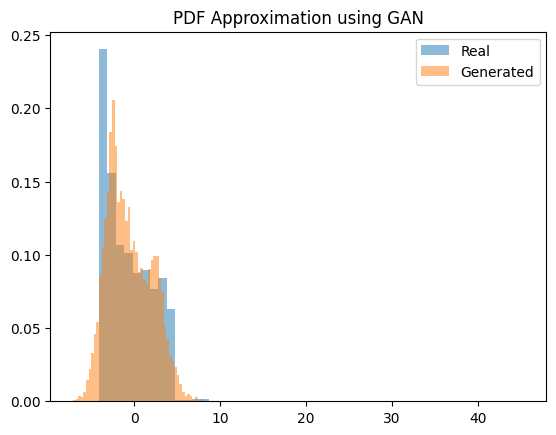

In [40]:
with torch.no_grad():
    noise = torch.randn(7000, 1)
    generated = G(noise).numpy()
plt.hist(z, bins=50, density=True, alpha=0.5, label="Real")
plt.hist(generated, bins=50, density=True, alpha=0.5, label="Generated")
plt.legend()
plt.title("PDF Approximation using GAN")
plt.show()